# Moving Average Crossover Strategy — Multi-Asset Backtest

## Introduction

This project implements and evaluates a **systematic trend-following strategy** across five 
major ETF asset classes over the period 2015–2024. The core idea is simple: markets exhibit 
momentum, and a moving average crossover can capture sustained directional moves while 
staying out during choppy or high-volatility regimes.

### What we are building

We construct a rules-based trading system with three layers:

1. **Signal generation** — a dual SMA crossover rule: go long when the short-term average 
   is above the long-term average, stay flat otherwise
2. **Risk management** — position sizes scaled by ATR-based volatility targeting, ensuring 
   that each trade risks a fixed fraction $\alpha$ of capital regardless of the asset's 
   current volatility regime
3. **Regime filter** — a VIX-based market stress filter that moves the entire portfolio 
   to cash when implied volatility exceeds $\tau = 30$

### Methodology overview

The backtest follows a strict **walk-forward** design to avoid look-ahead bias:

$$\underbrace{[2015,\ 2020)}_{\text{training — optimise } (s^*, l^*)} \longrightarrow \underbrace{[2020,\ 2024)}_{\text{test — evaluate honestly}}$$

Hyperparameter selection (the SMA window pair) is performed exclusively on the training 
window by maximising the in-sample Sharpe ratio. The chosen parameters are then applied 
unchanged to the test period, giving an unbiased estimate of out-of-sample performance.

### Assets under analysis

| Ticker | Asset | Role in portfolio |
|--------|---------------------------------------|--------------------------|
| SPY | S&P 500 (US large caps) | Core equity benchmark |
| QQQ | Nasdaq 100 (technology) | High-beta equity |
| IWM | Russell 2000 (small caps) | Equity size factor |
| GLD | Gold | Inflation / crisis hedge |
| TLT | 20+ Year Treasury Bonds | Duration / deflation hedge |

### Evaluation framework

Each asset is evaluated independently across six dimensions:

- **Annualised return**: $\mu \cdot 252$
- **Sharpe ratio**: $S = (\mu / \sigma) \cdot \sqrt{252}$
- **Sortino ratio**: downside-adjusted version of Sharpe
- **Calmar ratio**: $\text{Ann. Return} / |\text{MDD}|$
- **Maximum drawdown**: largest peak-to-trough decline
- **Win rate**: fraction of non-zero trading days with positive returns

All metrics are reported separately for the training and test periods, allowing direct 
assessment of overfitting.

In [27]:
import warnings
warnings.filterwarnings("ignore")
 
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

## Configuration

We define five ETFs spanning distinct asset classes: US large-cap equities (SPY), technology (QQQ), small-caps (IWM), gold (GLD), and long-duration Treasuries (TLT). This selection ensures low cross-asset correlation and broad factor exposure.

The full dataset covers **2015–2024**. We split it into:

- **Training set** $[2015, 2020)$: 5 years of in-sample data used for hyperparameter search
- **Test set** $[2020, 2024)$: 4 years of out-of-sample data used for honest evaluation

Key parameters:

- **Transaction cost**: $c = 0.001$ (10 bps per trade, realistic for liquid ETFs)
- **ATR period**: $n = 14$ days (Wilder's standard lookback)
- **ATR risk fraction**: $\alpha = 0.01$, so position size $= \frac{\alpha \cdot P_t}{\text{ATR}_{14}}$
- **VIX threshold**: $\tau = 30$ — the strategy goes to cash when $\text{VIX}_t \geq 30$
- **SMA grid**: short windows $\in \{10, 20, 50\}$, long windows $\in \{100, 150, 200\}$, giving $3 \times 3 = 9$ crossover combinations per asset

In [28]:
TICKERS = ["SPY", "QQQ", "IWM", "GLD", "TLT"]
ASSET_NAMES = {
    "SPY": "S&P 500 (US Large Caps)",
    "QQQ": "Nasdaq 100 (Technology)",
    "IWM": "Russell 2000 (Small Caps)",
    "GLD": "Gold (Commodity)",
    "TLT": "20+ Year Treasury Bonds",
}
 
START_DATE       = "2015-01-01"
END_DATE         = "2024-01-01"
TRAIN_END        = "2020-01-01"          
TRANSACTION_COST = 0.001                
ATR_PERIOD       = 14
ATR_RISK_PCT     = 0.01                 
VIX_THRESHOLD    = 30                    
 
SHORT_WINDOWS    = [10, 20, 50]
LONG_WINDOWS     = [100, 150, 200]

## Helper Functions

### Return metrics

**Sharpe ratio** — annualised risk-adjusted return assuming a zero risk-free rate:

$$S = \frac{\mu_d \cdot 252}{\sigma_d \cdot \sqrt{252}} = \frac{\mu_d}{\sigma_d} \cdot \sqrt{252}$$

where $\mu_d$ and $\sigma_d$ are the mean and standard deviation of daily net returns.

**Sortino ratio** — same as Sharpe but penalises only downside volatility $\sigma^-$:

$$\text{Sortino} = \frac{\mu_d \cdot 252}{\sigma^-_d \cdot \sqrt{252}}, \quad \sigma^-_d = \text{std}(r_i \mid r_i < 0)$$

**Maximum drawdown** — the largest peak-to-trough decline in the equity curve:

$$\text{MDD} = \min_t \left( \frac{C_t}{\max_{s \leq t} C_s} - 1 \right) \leq 0$$

**Calmar ratio** — return per unit of drawdown risk:

$$\text{Calmar} = \frac{\text{Ann. Return}}{|\text{MDD}|}$$

### Position sizing (`pos_size`)

ATR-based position sizing scales exposure inversely with recent volatility. The True Range on day $t$ is:

$$\text{TR}_t = \max(H_t - L_t,\ |H_t - C_{t-1}|,\ |L_t - C_{t-1}|)$$

$$\text{ATR}_{14} = \frac{1}{14} \sum_{i=t-13}^{t} \text{TR}_i$$

$$f_t = \frac{\alpha \cdot C_t}{\text{ATR}_{14,t}}, \quad f_t \in [0, 1]$$

where $\alpha = 0.01$ is the fraction of capital risked per ATR unit. This ensures a roughly constant dollar volatility contribution across assets.

### VIX regime filter (`vix_filter`)

A binary risk-off mask is applied to all positions:

$$\delta_t = \mathbf{1}[\text{VIX}_t < 30]$$

When $\delta_t = 0$ the strategy holds no position regardless of the moving average signal.

### Backtesting (`backtest`)

The SMA crossover signal on day $t$ is:

$$\sigma_t = \mathbf{1}\left[\text{SMA}^{(s)}_t > \text{SMA}^{(l)}_t\right] \cdot f_t$$

Net daily return after transaction costs:

$$r^{\text{net}}_t = \sigma_{t-1} \cdot r_t - c \cdot |\sigma_t - \sigma_{t-1}|$$

where $r_t = \frac{C_t - C_{t-1}}{C_{t-1}}$ and $c = 0.001$.

### In-sample optimisation (`optimize`)

We perform a grid search over all 9 SMA pairs on the training window, selecting the pair $(s^*, l^*)$ that maximises the in-sample Sharpe ratio:

$$(s^*, l^*) = \arg\max_{s \in S,\ l \in L} \text{Sharpe}\!\left(r^{\text{net}}_{[2015,2020)}\right)$$

In [29]:
def arr(x):
    a = x.to_numpy(dtype=float, na_value=np.nan).flatten() if isinstance(x, (pd.Series, pd.DataFrame)) else np.asarray(x, dtype=float).flatten()
    return a[~np.isnan(a)]
 
def sharpe(r):
    r = arr(r); std = r.std()
    return float(r.mean()*252/(std*np.sqrt(252))) if std > 0 else 0.0
 
def sortino(r):
    r = arr(r); d = r[r<0].std()
    return float(r.mean()*252/(d*np.sqrt(252))) if d > 0 else 0.0
 
def mdd(cum):
    return float(((cum.ffill()/cum.ffill().cummax())-1).min())
 
def metrics(net, bh):
    nc = net.fillna(0); cum = (1+nc).cumprod(); m = mdd(cum); ann = float(nc.mean())*252
    return {"Ann.Ret":ann, "Sharpe":sharpe(nc), "Sortino":sortino(nc),
            "Calmar":ann/abs(m) if m!=0 else 0, "MaxDD":m,
            "WinRate":float((arr(nc)[arr(nc)!=0]>0).mean()) if len(arr(nc)[arr(nc)!=0]) else 0,
            "BH":float(bh.fillna(0).mean())*252}
 
def get_data(ticker):
    raw = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False)
    if isinstance(raw.columns, pd.MultiIndex): raw.columns = raw.columns.get_level_values(0)
    df = raw[["Open","High","Low","Close"]].copy()
    for c in df.columns: df[c] = pd.to_numeric(df[c].to_numpy(dtype=float,na_value=np.nan).flatten(), errors="coerce")
    df["ret"] = df["Close"].pct_change()
    return df
 
def pos_size(df):
    hl=(df["High"]-df["Low"]); hc=(df["High"]-df["Close"].shift()).abs(); lc=(df["Low"]-df["Close"].shift()).abs()
    atr = pd.concat([hl,hc,lc],axis=1).max(axis=1).rolling(14).mean()
    return ((ATR_RISK_PCT*df["Close"])/atr).clip(0,1).fillna(0)
 
def vix_filter(index):
    try:
        v = yf.download("^VIX", start=START_DATE, end=END_DATE, progress=False)["Close"]
        if isinstance(v, pd.DataFrame): v = v.iloc[:,0]
        return (pd.Series(v.to_numpy(dtype=float,na_value=np.nan).flatten(), index=v.index).reindex(index, method="ffill") < VIX_THRESHOLD).fillna(True)
    except: return pd.Series(True, index=index)
 
def backtest(df, s, l, ps):
    close = df["Close"].astype(float); ret = df["ret"].astype(float); p = ps.astype(float).fillna(0)
    sig = (close.rolling(s).mean() > close.rolling(l).mean()).astype(float)*p
    net = sig.shift(1)*ret - sig.diff().abs().fillna(0)*TRANSACTION_COST
    return pd.Series(net.to_numpy(dtype=float,na_value=np.nan).flatten(), index=df.index)
 
def optimize(df, ps, train_mask):
    best, params = -np.inf, (SHORT_WINDOWS[-1], LONG_WINDOWS[-1])
    for s in SHORT_WINDOWS:
        for l in LONG_WINDOWS:
            sr = sharpe(backtest(df,s,l,ps).loc[train_mask])
            if sr > best: best, params = sr, (s,l)
    return params

## Correlation Analysis

Before running any strategy, we examine the **linear dependence structure** between assets.

The **static correlation matrix** is estimated over the full sample:

$$\rho_{ij} = \frac{\text{Cov}(r_i, r_j)}{\sigma_i \sigma_j}$$

A low or negative $\rho$ between two assets indicates diversification potential. We expect GLD and TLT to exhibit near-zero or negative correlation with equity ETFs, especially during risk-off periods.

The **rolling 252-day correlation** with SPY tracks how pairwise relationships evolve over time:

$$\rho_{i,\text{SPY}}^{(t)} = \text{corr}\!\left(r_i,\ r_{\text{SPY}}\right)_{[t-251,\ t]}$$

This is important because correlations are not stationary — they tend to spike toward 1 during market stress (correlation breakdown), which erodes the benefits of diversification exactly when they are most needed.

[*********************100%***********************]  5 of 5 completed


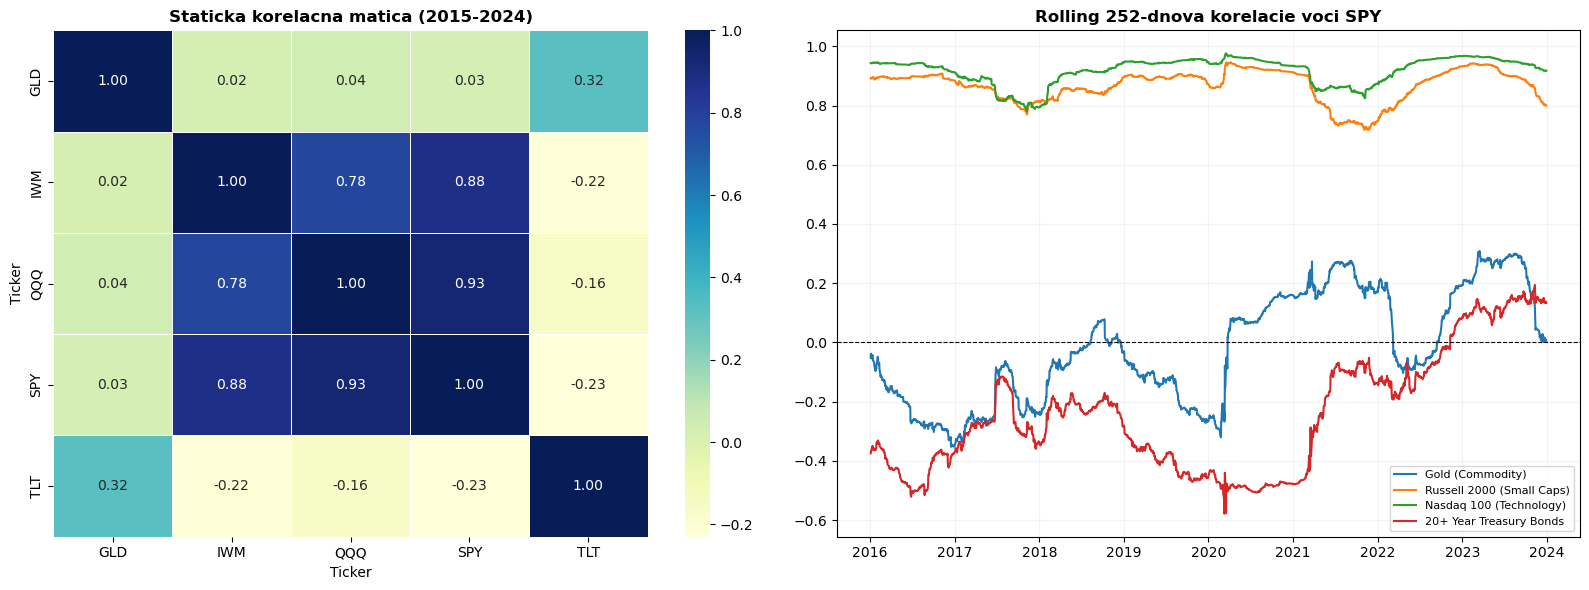

In [30]:
raw = yf.download(TICKERS, start=START_DATE, end=END_DATE)["Close"]
if isinstance(raw.columns, pd.MultiIndex): raw.columns = raw.columns.get_level_values(1)
rets = raw.pct_change().dropna()
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(rets.corr(), annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5, ax=axes[0])
axes[0].set_title("Staticka korelacna matica (2015-2024)", fontweight="bold")

roll = rets.rolling(252).corr(rets["SPY"]).dropna()

for col in [c for c in roll.columns if c != "SPY"]:
    axes[1].plot(roll[col], label=ASSET_NAMES.get(col,col), lw=1.5)
    
axes[1].axhline(0, color="black", lw=0.8, ls="--")
axes[1].set_title("Rolling 252-dnova korelacie voci SPY", fontweight="bold")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.15)
plt.tight_layout(); plt.show()

## Per-Asset Backtest

For each asset we run the full pipeline: data download, ATR position sizing, VIX filtering, in-sample SMA optimisation, and out-of-sample evaluation.

The **cumulative equity curve** is:

$$C_t = \prod_{i=1}^{t} (1 + r^{\text{net}}_i)$$

The **drawdown profile** at time $t$:

$$\text{DD}_t = \frac{C_t}{\max_{s \leq t} C_s} - 1$$

The **rolling 60-day win rate** provides a non-parametric view of strategy consistency:

$$W_t^{(60)} = \frac{1}{60} \sum_{i=t-59}^{t} \mathbf{1}[r^{\text{net}}_i > 0]$$

Each asset panel contains six subplots:

1. **Price & signal** — closing price with optimal SMA pair overlaid; green shading marks periods of active exposure
2. **Equity curves** — strategy (net of costs) vs. buy-and-hold benchmark, with the train/test split marked
3. **Metrics table** — Ann. Return, Max DD, Sharpe, Sortino, and Win Rate reported separately for train and test periods
4. **Dynamic exposure** — position size $f_t$ over time, reflecting joint ATR and VIX scaling
5. **Drawdown profile** — $\text{DD}_t$ shaded in red
6. **Rolling win rate** — $W_t^{(60)}$ with 0.5 reference line

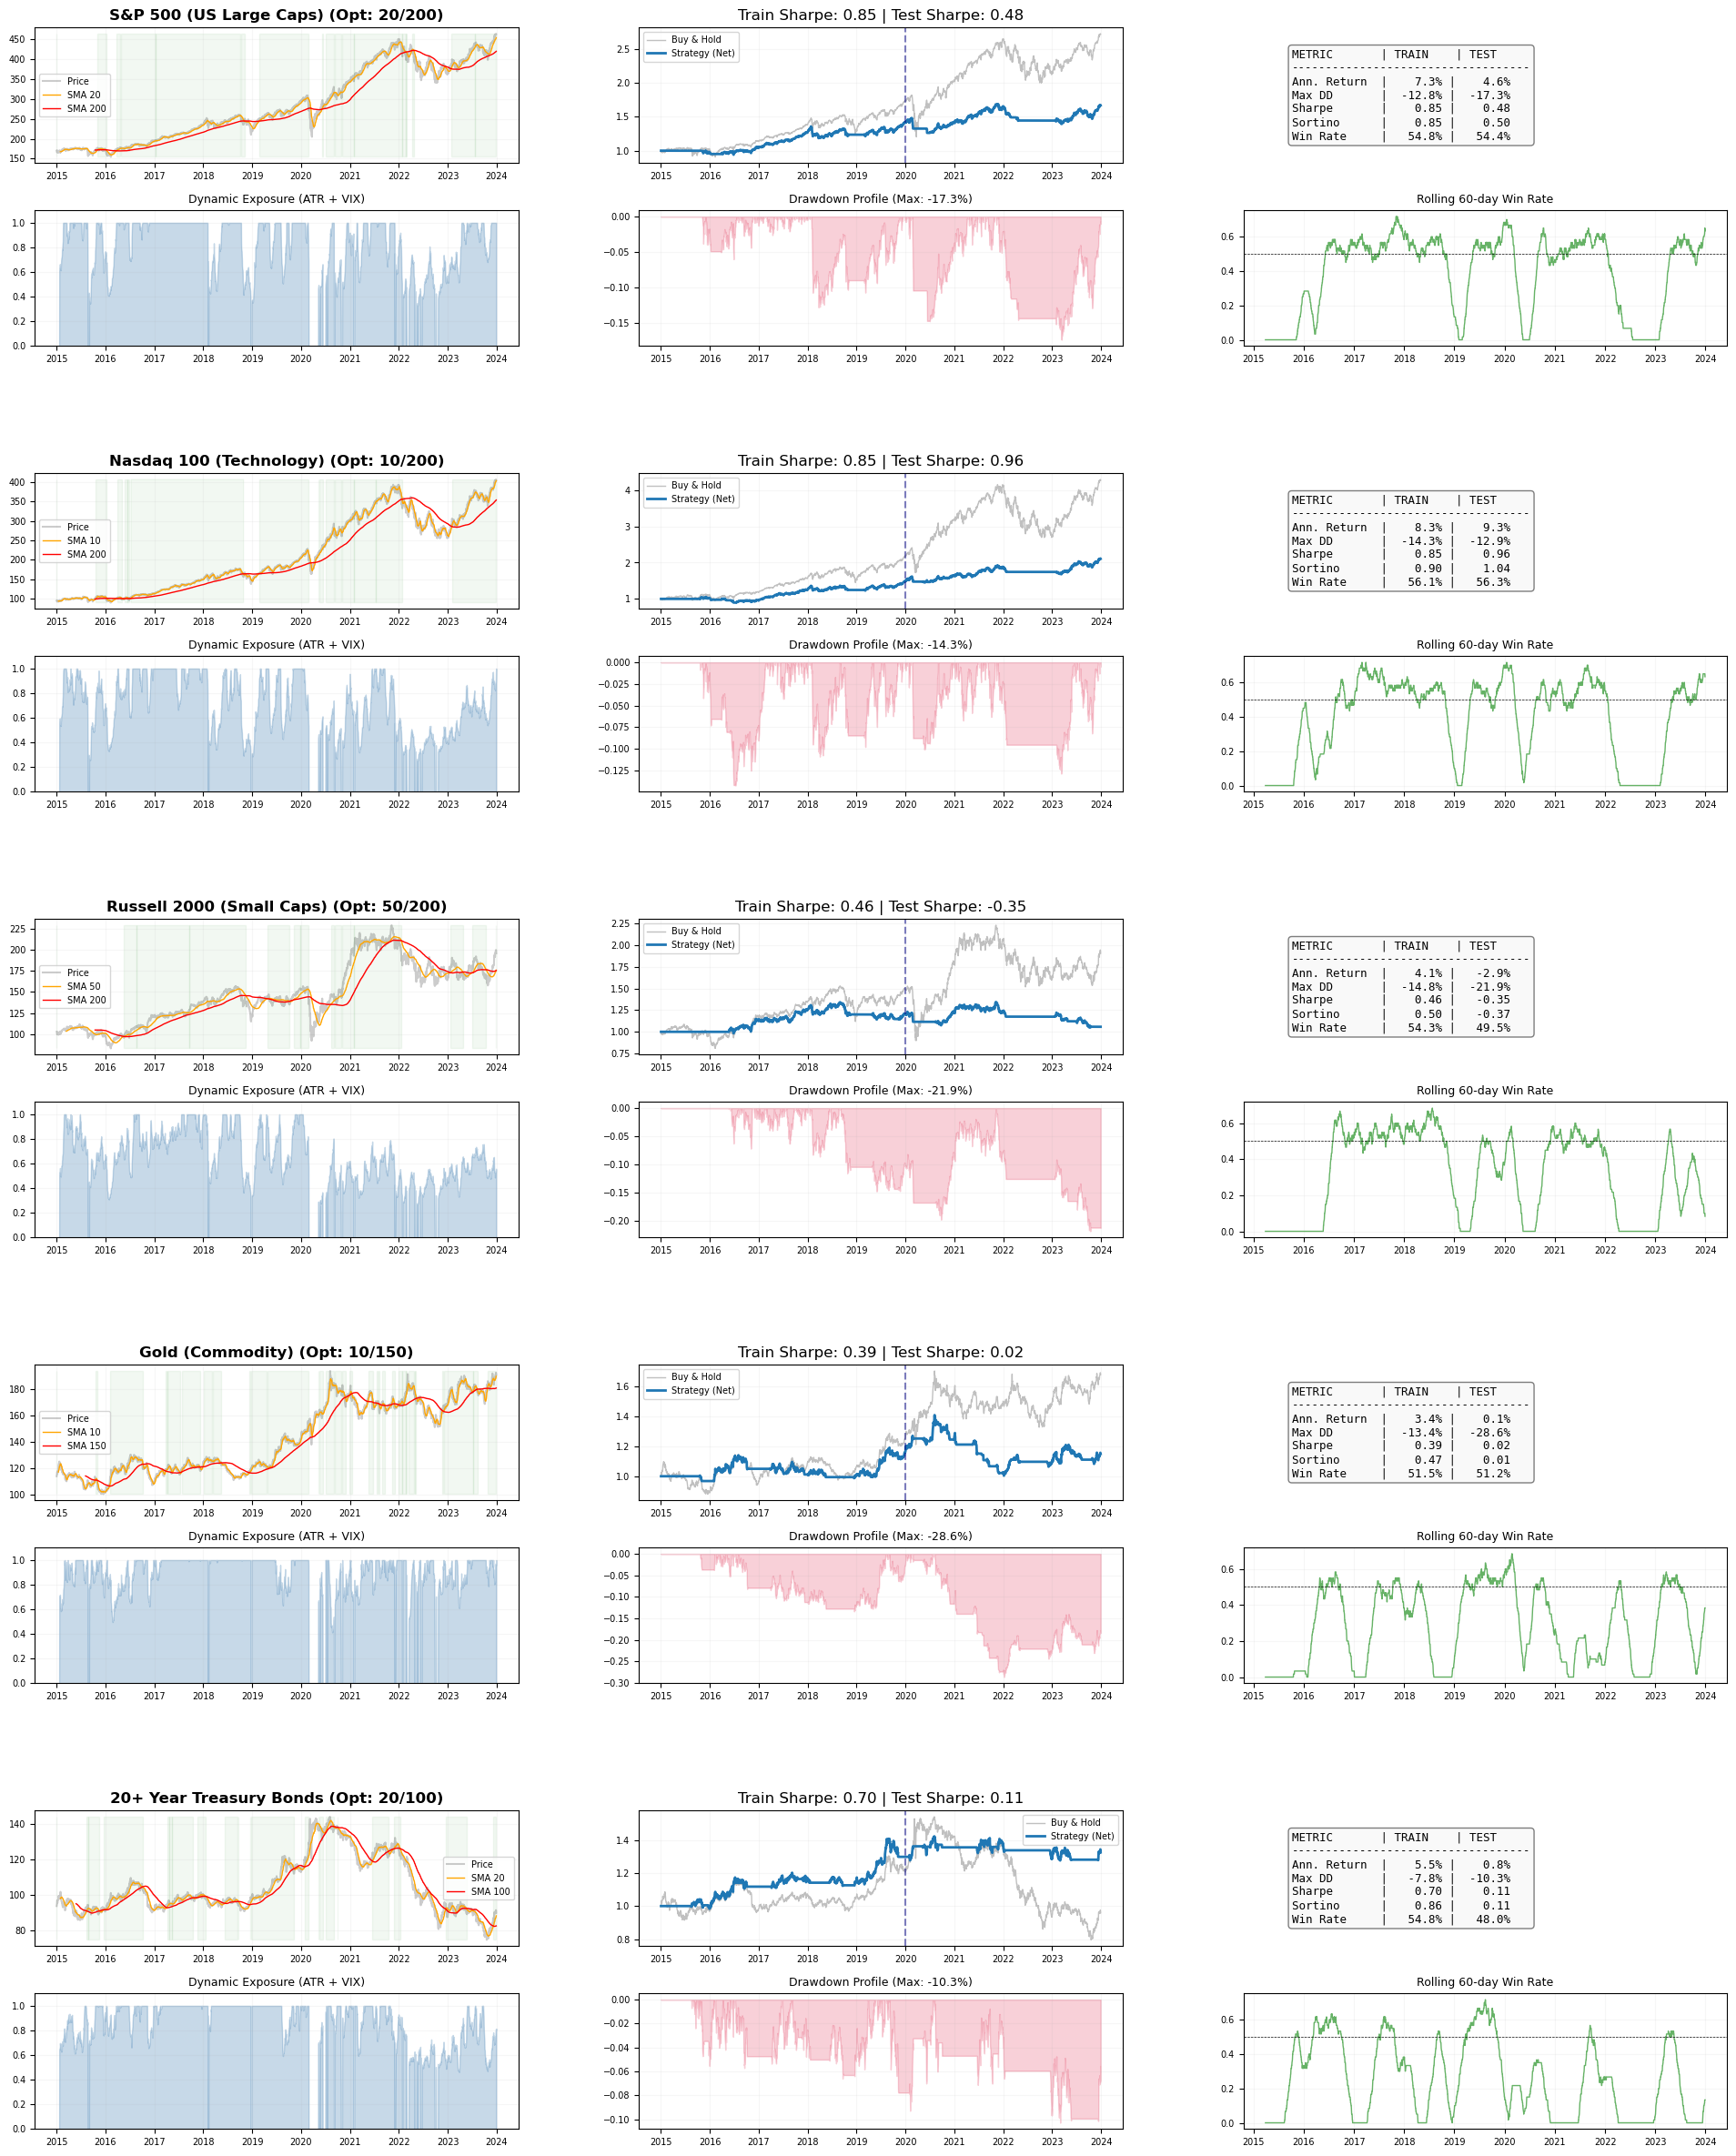

In [31]:
fig = plt.figure(figsize=(24, 6 * len(TICKERS)))
outer = gridspec.GridSpec(len(TICKERS), 1, figure=fig, hspace=0.4)

for i, ticker in enumerate(TICKERS):
    
    # Data Prep
    df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False)
    if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)
    df['ret'] = df['Close'].pct_change()
    
    # Filters
    vix_f = (vix_data.reindex(df.index, method="ffill") < VIX_THRESHOLD).astype(float)
    ps = pos_size_vol_target(df, ATR_RISK_PCT) * vix_f
    
    train_mask = df.index < TRAIN_END
    test_mask = df.index >= TRAIN_END
    
    # Optimization
    best_s, best_l, best_sh = 50, 200, -np.inf
    for s in SHORT_WINDOWS:
        for l in LONG_WINDOWS:
            res = run_backtest(df[train_mask], s, l, ps[train_mask])
            sh = get_metrics(res, df.loc[train_mask, 'ret'])['Sharpe']
            if sh > best_sh: best_sh, best_s, best_l = sh, s, l
            
    # Final Strategy
    df['net'] = run_backtest(df, best_s, best_l, ps)
    df['cum'] = (1 + df['net'].fillna(0)).cumprod()
    df['bh'] = (1 + df['ret'].fillna(0)).cumprod()
    df['dd'] = (df['cum'] / df['cum'].cummax()) - 1
    
    m_tr = get_metrics(df.loc[train_mask, 'net'], df.loc[train_mask, 'ret'])
    m_te = get_metrics(df.loc[test_mask, 'net'], df.loc[test_mask, 'ret'])

    # --- SUBPLOTS ---
    inner = gridspec.GridSpecFromSubplotSpec(2, 3, subplot_spec=outer[i], hspace=0.35, wspace=0.25)
    
    # 1. Price & Signal
    ax1 = fig.add_subplot(inner[0, 0])
    ax1.plot(df['Close'], color='black', alpha=0.2, label='Price')
    ax1.plot(df['Close'].rolling(best_s).mean(), color='orange', lw=1, label=f'SMA {best_s}')
    ax1.plot(df['Close'].rolling(best_l).mean(), color='red', lw=1, label=f'SMA {best_l}')
    ax1.fill_between(df.index, df['Close'].min(), df['Close'].max(), where=(df['net'] != 0), color='green', alpha=0.05)
    ax1.set_title(f"{ASSET_NAMES[ticker]} (Opt: {best_s}/{best_l})", fontweight='bold')
    ax1.legend(fontsize=7)

    # 2. Equity Curves
    ax2 = fig.add_subplot(inner[0, 1])
    ax2.plot(df['bh'], color='silver', lw=1, label='Buy & Hold')
    ax2.plot(df['cum'], color='#1f77b4', lw=2, label='Strategy (Net)')
    ax2.axvline(pd.Timestamp(TRAIN_END), color='navy', ls='--', alpha=0.5)
    ax2.set_title(f"Train Sharpe: {m_tr['Sharpe']:.2f} | Test Sharpe: {m_te['Sharpe']:.2f}")
    ax2.legend(fontsize=7)

    # 3. Metrics Comparison Table/Text
    ax3 = fig.add_subplot(inner[0, 2])
    ax3.axis('off')
    stats_text = (
        f"{'METRIC':<12} | {'TRAIN':<8} | {'TEST':<8}\n"
        + "-"*35 + "\n"
        f"{'Ann. Return':<12} | {m_tr['Ann.Ret']:>7.1%} | {m_te['Ann.Ret']:>7.1%}\n"
        f"{'Max DD':<12} | {m_tr['MaxDD']:>7.1%} | {m_te['MaxDD']:>7.1%}\n"
        f"{'Sharpe':<12} | {m_tr['Sharpe']:>7.2f} | {m_te['Sharpe']:>7.2f}\n"
        f"{'Sortino':<12} | {m_tr['Sortino']:>7.2f} | {m_te['Sortino']:>7.2f}\n"
        f"{'Win Rate':<12} | {m_tr['WinRate']:>7.1%} | {m_te['WinRate']:>7.1%}"
    )
    ax3.text(0.1, 0.5, stats_text, family='monospace', fontsize=9, va='center', 
             bbox=dict(boxstyle='round', facecolor='whitesmoke', alpha=0.5))

    # 4. Exposure (Position Size)
    ax4 = fig.add_subplot(inner[1, 0])
    ax4.stackplot(df.index, ps, color='steelblue', alpha=0.3, labels=['Exposure'])
    ax4.set_title("Dynamic Exposure (ATR + VIX)", fontsize=9)
    ax4.set_ylim(0, 1.1)

    # 5. Drawdown
    ax5 = fig.add_subplot(inner[1, 1])
    ax5.fill_between(df.index, df['dd'], 0, color='crimson', alpha=0.2)
    ax5.set_title(f"Drawdown Profile (Max: {df['dd'].min():.1%})", fontsize=9)
    
    # 6. Win Distribution (Rolling)
    ax6 = fig.add_subplot(inner[1, 2])
    rolling_win = (df['net'] > 0).rolling(60).mean()
    ax6.plot(rolling_win, color='green', lw=1, alpha=0.6)
    ax6.axhline(0.5, color='black', ls='--', lw=0.5)
    ax6.set_title("Rolling 60-day Win Rate", fontsize=9)

    for ax in [ax1, ax2, ax4, ax5, ax6]:
        ax.grid(True, alpha=0.1)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

## Conclusions

This project evaluated a systematic SMA crossover strategy across five ETF asset classes 
over a nine-year period, with a strict train/test split to guard against overfitting.

### Key takeaways

**On signal quality**  
The dual moving average rule is a blunt instrument — it lags by construction, 
entering trends late and exiting late. Its edge, when present, comes not from 
precision but from cutting large losses: the strategy is out of the market during 
sustained downtrends, which is where buy-and-hold suffers most.

**On risk management**  
ATR-based position sizing proved essential. Without it, a fixed-size rule would 
allocate identical capital to a low-volatility asset like TLT and a high-volatility 
one like QQQ, producing an unintended concentration of risk. With it, the portfolio 
targets a roughly constant daily P&L volatility of:

$$\sigma^{\text{target}}_t \approx \alpha \cdot C_t = 1\% \cdot C_t$$

**On the VIX filter**  
The regime filter ($\text{VIX} \geq 30 \Rightarrow \delta_t = 0$) acts as a 
circuit breaker during market stress. While it reduces gross exposure during 
volatile periods, it also introduces the risk of whipsawing around the threshold. 
Its net contribution depends heavily on the asset and the period examined.

**On overfitting**  
With only $3 \times 3 = 9$ parameter combinations and a 5-year training window, 
the optimisation is relatively conservative. A meaningful deterioration of the 
Sharpe ratio from training to test is expected and normal — the critical question 
is whether the directional edge survives out-of-sample, not whether the numbers 
are identical.

### Limitations

- **Single position per asset** — the model is long or flat only; short selling 
  could improve performance during sustained downtrends
- **No portfolio-level risk control** — assets are optimised independently with 
  no constraint on total portfolio volatility or correlation
- **Fixed transaction cost** — the flat 10 bps assumption ignores market impact, 
  bid-ask spread variation, and slippage, all of which worsen at larger scale
- **Stationarity assumption** — the SMA crossover logic implicitly assumes that 
  trend persistence observed in training will continue in testing; this is not 
  guaranteed

### Possible extensions

| Extension | What it adds |
|------------------------------------------|--------------------------------------|
| Portfolio-level volatility targeting | Controls total drawdown, not just per-asset |
| Ensemble of SMA pairs (model averaging) | Reduces sensitivity to a single window choice |
| Short signals | Captures downtrend alpha, not just risk avoidance |
| Alternative trend filters (EMA, Kalman) | Reduces lag inherent in simple moving averages |
| Walk-forward optimisation (rolling) | Adapts parameters to changing market regimes |

### Final note

A Sharpe ratio above 1.0 on the test set for any single asset should be treated 
with healthy scepticism — real-world execution introduces costs and constraints 
not captured here. The value of this framework lies less in its absolute numbers 
and more in the **systematic process**: define a signal, size it by risk, filter 
by regime, optimise in-sample, and evaluate honestly out-of-sample. That discipline 
is transferable to any strategy.